<a href="https://colab.research.google.com/github/JuanJGalindo/ML-Theory/blob/main/Juan_Jose_Galindo_Marquez_Ocho_Reinas_VClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema de las 8 reinas**

Realice la implementación del problema de las 8 reinas usando Algoritmos Genéticos

### **Population Instatiation**

The population will be represented as a matrix of $n$ rows (*Individuals*), where each of them is represented by a random integer array of length $8$ (*Gene*) with values ranging from $0$ to $7$ (*Zero-Based Index*).

Visualizing the gene representation as queens located in the Chessboard is interpreted as:

 - $i$-th position in the array, represents the column number in chessboard of the queen's location
 - The specific value of the array at the $i$-th position, represents the row number in chessboard of the queen's location

In [272]:
import numpy as np

In [273]:
def initialPopulation(n):
    '''
    Returns a (n, 8) matrix
    Each row represents a individual's gen with its 8 elements
    '''

    return np.random.randint(0, 8, size=(n,8))

In [274]:
population = initialPopulation(8)

### **Fitness Function Definition**

The 8 Queens Puzzle can be viewed from an optimization perspective as minimizing the number of attacking pairs of queens on the board. In a standard board with 8 queens, the maximum number of distinct pairs that can be formed is given by the combination formula:

$$\binom{8}{2} = \frac{8 \times 7}{2} = 28$$

Thus, if all 8 queens were placed such that every pair attacked each other, there would be 28 total conflicts, representing the scenario where all queens are located along the same row, column or diagonal. We can convert this minimization problem into a maximization task by defining our fitness function $\mathcal{L}$ as:

$$\mathcal{L} = 28 - \text{totalConflicts}$$

While checking conflicts using nested loops is computationally expensive, NumPy allows us to vectorize this calculation across the entire population using tensor broadcasting and upper-triangular masking.

#### **Pairwise Distance Tensors**

To evaluate conflicts across the board without explicit loops, we compute pairwise distance tensors for both rows and columns:

* **Row Difference Tensor:** By expanding the population array of shape $(N, 8)$ into dimensions $(N, 8, 1)$ and $(N, 1, 8)$, NumPy broadcasts the subtraction across all pairs of queens. Taking the absolute value yields an $(N, 8, 8)$ tensor where element $(k, i, j)$ represents the row distance between queen $i$ and queen $j$ for individual $k$:

$$\vert{}R_i - R_j\vert{}$$

* **Column Difference Matrix:** Since queens are implicitly fixed to columns $0$ through $7$ by array indexing, the column distances are identical across all individuals. Using the column index vector $\mathbf{c} = [0, 1, \dots, 7]$, broadcasting yields an $(8, 8)$ matrix where element $(i, j)$ represents the absolute horizontal distance:

$$\vert{}i - j\vert{}$$

#### **Identifying Conflicts via Pairwise Distances**

Geometrically, two distinct queens at positions $(i, R_i)$ and $(j, R_j)$ are in conflict if they share a line of attack:

1. **Row Conflicts:** Queens $i$ and $j$ occupy the same row if their vertical distance is zero ($\vert{}R_i - R_j\vert{} = 0$).
2. **Diagonal Conflicts:** Queens $i$ and $j$ lie on the same diagonal if their vertical distance equals their horizontal distance ($\vert{}R_i - R_j\vert{} = \vert{}i - j\vert{}$), corresponding to a diagonal line with a slope of $\pm 1$.

***Note:** Column conflicts are impossible by design, as each array index represents a unique column.*

#### **Upper Triangular Masking and Its Importance**

Evaluating all entries in the $8 \times 8$ distance matrix introduces two critical issues:

1. **Self-Comparison ($i = j$):** A queen compared with itself yields $\vert{}R_i - R_i\vert{} = 0$ and $\vert{}i - i\vert{} = 0$, falsely registering both row and diagonal conflicts.
2. **Double Counting ($i \neq j$):** Pairwise distance matrices are symmetric ($\vert{}R_i - R_j\vert{} = \vert{}R_j - R_i\vert{}$). Counting both pair $(i, j)$ and pair $(j, i)$ doubles the actual conflict count.

To resolve both issues, an upper triangular boolean mask is applied. Setting $k=1$ excludes the main diagonal ($i = j$) and zeroes out the lower triangular entries ($i > j$).

Filtering the row and diagonal condition matrices with this mask ensures that only unique pairs $(i, j)$ where $i < j$ are evaluated. Summing the resulting boolean array across axes $(1, 2)$ for each individual yields the exact count of unique conflicting pairs on the board.

In [275]:
def fitnessFunction(population):
    '''
    Returns a vector of size n (Population Size) such that
    each element is the fitness value for each individual.

    Usage of loops is prevented, we will use Numpy's capabilities
    by performing broadcasting and boolean masking operations for
    calculating all the conflicts present in each gene
    '''

    # 1. Compute pairwise row differences for all genes
    diffRows = np.abs(population[:, :, np.newaxis] - population[:, np.newaxis, :])

    # 2. Compute pairwise column differences (constant across population)
    cols = np.arange(8)
    diffCols = np.abs(cols[:, np.newaxis] - cols)

    # 3. Create an upper triangular mask to avoid self-comparison and double-counting
    mask = np.triu(np.ones((8, 8), dtype=bool), k=1)

    # 4. Identify conflicts
    rowConflicts = (diffRows == 0) & mask
    diagConflicts = (diffRows == diffCols) & mask

    # 5. Calculate total conflicts
    totalConflicts = np.sum(rowConflicts | diagConflicts, axis=(1, 2))

    # 6. Subtract from max possible pairs (28)
    return 28 - totalConflicts


In [276]:
population

array([[0, 4, 1, 4, 2, 4, 3, 0],
       [4, 5, 2, 2, 2, 1, 1, 5],
       [1, 2, 2, 1, 1, 5, 6, 0],
       [2, 3, 2, 6, 6, 3, 1, 0],
       [4, 6, 2, 0, 0, 6, 5, 1],
       [4, 6, 1, 0, 3, 7, 7, 2],
       [0, 1, 6, 5, 1, 0, 7, 6],
       [0, 3, 3, 6, 3, 2, 7, 1]])

In [277]:
fitness = fitnessFunction(population)
fitness

array([21, 17, 19, 20, 22, 24, 21, 23])

### **Selection Process**
Once the population is instantiated, the evaluation yields a fitness array denoted as $F = [f_1, f_2, \dots, f_N]$, where $f_{i}$ represents the raw performance score of individual $i$. To determine mating pairs for the succeeding generation, this array must be mapped into a valid probability distribution vector $P = [p_1, p_2, \dots, p_N]$, where $p_{i}$ represents the selection probability of individual $i$, ensuring that $p_i \ge 0$ and $\sum_{i=1}^{N} p_i = 1$. The choice of scaling methodology dictates the selection pressure and directly balances exploration and exploitation within the search space.

---

**Discrete Normalization**

This method converts fitness scores directly into relative probabilities by scaling each individual against the total sum of the population's performance. Because 8 Queens fitness scores are naturally high and clustered closely together (e.g., 24 versus 26 out of 28), this linear heuristic fails to create meaningful separation. The resulting implications are a highly diluted selection pressure where top-performing boards have virtually the same reproductive chances as mediocre ones, causing the algorithm to mimic an inefficient uniform random search.

$$p_{i}=\frac{f_{i}}{\sum _{j=1}^{N}f_{j}}$$

---

**Min-Max Normalized Scaling**

This heuristic shifts and rescales the fitness array relative to the absolute worst and best individuals within the current generation. By setting the generation's minimum performance to zero, it guarantees the systematic elimination of the worst-performing genes from the mating pool while magnifying the relative differences among the remaining individuals. The primary implication is a dynamic selection pressure that adapts automatically to population diversity, heavily favoring superior chromosomes without exponentially crushing average ones.

$$p_{i}=\frac{f_{i}-\min (F)}{\sum _{j=1}^{N}(f_{j}-\min (F))}$$

To mitigate the absolute exclusion of the lowest performer and preserve residual genetic diversity, the heuristic can be adjusted by defining a strict minimum probability floor $p_{\text{min}} > 0$. This modification ensures that the worst-performing individual retains a non-zero selection probability, balancing exploration by preventing the immediate elimination of potentially unique structural building blocks. The remaining probability mass $(1 - N \cdot p_{\text{min}})$ is then distributed proportionally based on relative fitness differences.

$$p_{i}=p_{\text{min}}+(1-N\cdot p_{\text{min}})\cdot \frac{f_{i}-\min (F)}{\sum _{j=1}^{N}(f_{j}-\min (F))}$$

***Note:** To ensure a valid probability distribution, the user-defined parameter must satisfy the constraint $p_{\text{min}} \le \frac{1}{N}.$*

---

**Softmax Scaling**

This method routes the fitness array through an exponential function to exaggerate arithmetic differences non-linearly. The underlying heuristic ensures that even marginal advantages (such as a score of 27 versus 26) translate into an overwhelming dominance in the probability space. The core implication is an extremely aggressive exploitative selection pressure that drives rapid convergence toward near-optimal solutions, though it carries a severe risk of capturing the population in local optima by prematurely destroying genetic diversity.

$$p_{i}=\frac{e^{f_{i}}}{\sum _{j=1}^{N}e^{f_{j}}}$$

***Note:** Mutation process can partially recover genetic diversity destruction*

In [278]:
def discreteNormalization(fitness: np.ndarray):
    """
    Converts a raw fitness array into a discrete normalized selection probability vector.

    Parameters:
        fitness (np.ndarray): 1D array of performance scores for the population.

    Returns:
        np.ndarray: Probability Distribution Vector.
    """
    return fitness/np.sum(fitness)


def minMaxNormalization(fitness: np.ndarray, min_prob: float = 0.0)-> np.ndarray:
    """
    Converts a raw fitness array into a MinMax normalized selection probability vector.
    Supports a baseline probability floor (min_prob) to preserve genetic diversity.

    Parameters:
        fitness (np.ndarray): 1D array of performance scores for the population.
        min_prob (float): Target selection probability for the worst individual (>= 0).

    Returns:
        np.ndarray: Probability Distribution Vector.
    """
    n = len(fitness)

    # 1. Parameter Validation & Auto-Adjustment
    if min_prob < 0:
        min_prob = 0.0
        print(f"Adjusting min_prob to lower bound: {min_prob:.4f}")

    elif min_prob > 1 / n:
        min_prob = 1 / n
        print(f"Adjusting min_prob to upper bound (1/N): {min_prob:.4f}")

    # 2. Statistics Calculation
    f_min = np.min(fitness)
    f_shifted = fitness - f_min
    shifted_sum = np.sum(f_shifted)

    # 3. Homogeneous Population Edge Case (Avoids 0/0 division)
    if np.isclose(shifted_sum, 0.0):
        return np.full(n, 1.0 / n)

    # 4. Scaling Calculation
    remaining_mass = 1.0 - (n * min_prob)
    scaling = f_shifted / shifted_sum

    return min_prob + (remaining_mass * scaling)


def softmaxNormalization(fitness: np.ndarray, temperature: float = 1.0)-> np.ndarray:
    """
    Converts a raw fitness array into a Softmax normalized selection probability vector.
    Supports a temperature scaling factor to model softmax curve.

    Parameters:
        fitness (np.ndarray): 1D array of performance scores for the population.
        temperature (float):  Hyperparameter that control the sharpness or
                              randomness of the resulting probability distribution.

    Returns:
        np.ndarray: Probability Distribution Vector.
    """
    # 1. Parameter Validation
    # Prevent division by zero or negative temperatures
    if temperature <= 0:
        temperature = 1.0
        print(f"Adjusting temperature to standard value: {temperature:.2f}")

    # 2. Scaling Calculation
    shifted_fitness = (fitness - np.max(fitness)) / temperature
    exp_fitness = np.exp(shifted_fitness)

    return exp_fitness / np.sum(exp_fitness)

Discrete Normalization: [0.1257 0.1018 0.1138 0.1198 0.1317 0.1437 0.1257 0.1377]

Min-Max Normalization (no min_prob): [0.129  0.     0.0645 0.0968 0.1613 0.2258 0.129  0.1935]

Min-Max Normalization (min_prob=0.005): [0.1284 0.02   0.0742 0.1013 0.1555 0.2097 0.1284 0.1826]

Softmax Normalization (temp=1.0): [3.060e-02 6.000e-04 4.100e-03 1.120e-02 8.310e-02 6.140e-01 3.060e-02
 2.259e-01]

Softmax Normalization (temp=0.5): [2.100e-03 0.000e+00 0.000e+00 3.000e-04 1.580e-02 8.628e-01 2.100e-03
 1.168e-01]

Softmax Normalization (temp=5.0): [0.118  0.053  0.0791 0.0966 0.1441 0.215  0.118  0.1761]



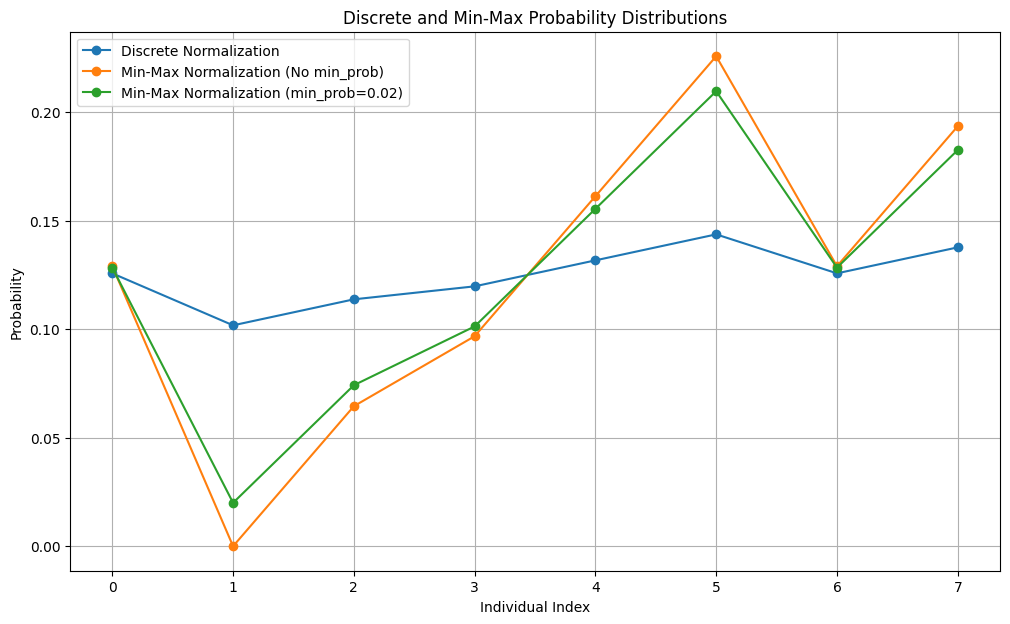

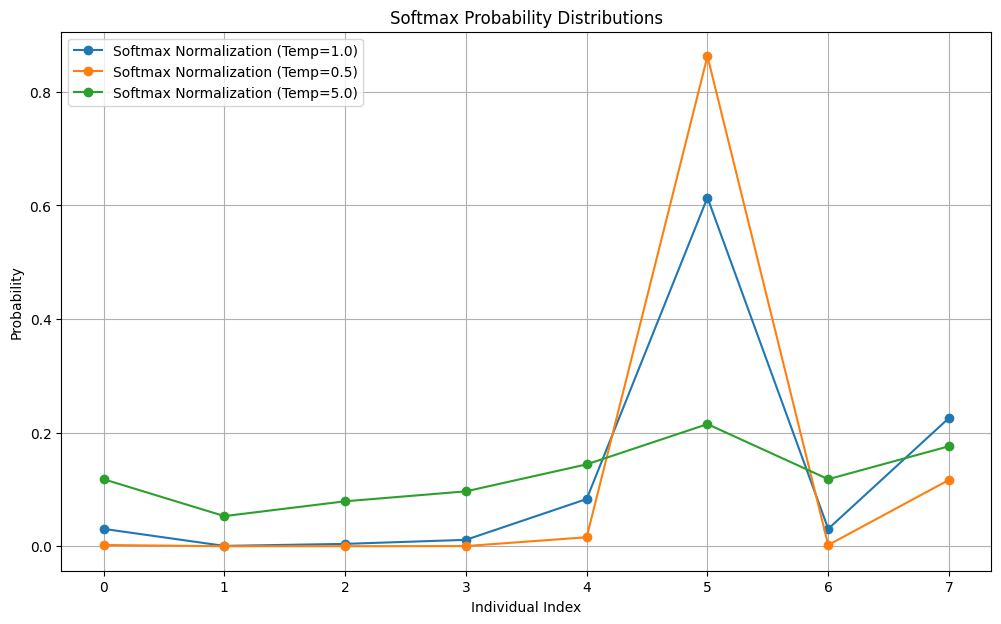

In [279]:
import matplotlib.pyplot as plt

probsD = discreteNormalization(fitness)
probsM0 = minMaxNormalization(fitness)
probsM1 = minMaxNormalization(fitness, min_prob=0.02)
probsS1 = softmaxNormalization(fitness)
probsS05 = softmaxNormalization(fitness, temperature=0.5)
probsS2 = softmaxNormalization(fitness, temperature=5.0)

print(f"Discrete Normalization: {np.round(probsD, 4)}\n")
print(f"Min-Max Normalization (no min_prob): {np.round(probsM0, 4)}\n")
print(f"Min-Max Normalization (min_prob=0.005): {np.round(probsM1, 4)}\n")
print(f"Softmax Normalization (temp=1.0): {np.round(probsS1, 4)}\n")
print(f"Softmax Normalization (temp=0.5): {np.round(probsS05, 4)}\n")
print(f"Softmax Normalization (temp=5.0): {np.round(probsS2, 4)}\n")

# Plotting Discrete and Min-Max Normalization
plt.figure(figsize=(12, 7))
plt.plot(probsD, label='Discrete Normalization', marker='o')
plt.plot(probsM0, label='Min-Max Normalization (No min_prob)', marker='o')
plt.plot(probsM1, label='Min-Max Normalization (min_prob=0.02)', marker='o')

plt.title('Discrete and Min-Max Probability Distributions')
plt.xlabel('Individual Index')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Softmax Normalization
plt.figure(figsize=(12, 7))
plt.plot(probsS1, label='Softmax Normalization (Temp=1.0)', marker='o')
plt.plot(probsS05, label='Softmax Normalization (Temp=0.5)', marker='o')
plt.plot(probsS2, label='Softmax Normalization (Temp=5.0)', marker='o')

plt.title('Softmax Probability Distributions')
plt.xlabel('Individual Index')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

### **Selection Process - Revisited**

Once the probability distribution is obtained from the fitness scores of the given population, random indices are drawn from this probability distribution to select the final "mating" candidates from the population (a 1D array of length N) and is reshaped to a matrix of size (N/2, 2) representing all the "mating" pairs.

In [280]:
def selection(population, fitness, method='softmax', temperature=1.0, min_prob=0.0):
    """
    Draws from a probability distribution given by the fitness scores of the population
    a selection of indices which reshaped and applied to the population matrix,
    returns the "mating" pairs matrix.

    Parameters:
        population (np.ndarray): Matrix of shape (N, 8), encoding individual's genes.
        fitness (np.ndarray): 1D array of performance scores for the population.
        method (string): 'discrete' for Discrete Normalization,
                         'min_max' for MinMax Normalization and
                         'softmax' for Softmax Normalization.
        temperature (float): Hyperparameter for Softmax Normalization.
        min_prob (float): Target selection probability for the worst individual
                          in a MinMax Normalization Method (0 <= min_prob <= 1/N).

    Returns:
        np.ndarray: Mating Pairs Tensor of shape (N/2, 2, 8).
    """
    n = population.shape[0]

    # 1. Probability Distribution
    if method == 'discrete':
        probabilities = softmaxNormalization(fitness)

    elif method == 'min_max':
        probabilities = minMaxNormalization(fitness, min_prob)

    elif method == 'softmax':
        probabilities = softmaxNormalization(fitness, temperature)

    # 2. Index Selection
    selectedIndices = np.random.choice(n, size=n, p=probabilities)
    pairIndices = selectedIndices.reshape(-1, 2)

    matingPairs = population[pairIndices]

    return matingPairs

In [281]:
matingPairs = selection(population, fitness, method='softmax', temperature=5.0)
matingPairs

array([[[4, 6, 1, 0, 3, 7, 7, 2],
        [1, 2, 2, 1, 1, 5, 6, 0]],

       [[4, 6, 2, 0, 0, 6, 5, 1],
        [0, 3, 3, 6, 3, 2, 7, 1]],

       [[4, 6, 1, 0, 3, 7, 7, 2],
        [4, 6, 2, 0, 0, 6, 5, 1]],

       [[0, 3, 3, 6, 3, 2, 7, 1],
        [4, 6, 1, 0, 3, 7, 7, 2]]])

In [282]:
matingPairs[:, 1]

array([[1, 2, 2, 1, 1, 5, 6, 0],
       [0, 3, 3, 6, 3, 2, 7, 1],
       [4, 6, 2, 0, 0, 6, 5, 1],
       [4, 6, 1, 0, 3, 7, 7, 2]])

### **Cross-Over Process**
For each independent "mating" pair, a random generated split index dictates the coordinate boundary where the parental gene segments are cleaved and cross-combined. By utilizing logical broadcasting masks instead of sequential iterations, the process seamlessly synthesizes the genetic building blocks, outputting a unified descendant matrix of size (N, 8) that constitutes the non-mutated child population for the succeeding generation.


In [283]:
def crossover(matingPairs):
    """
    Cleaves the gene sequence of each parents pair at a certain random index,
    and cross-combines their gene sequences, resulting in two complementary
    gene sequences as their children.

    Parameters:
        matingPairs (np.ndarray): Tensor of shape (N/2, 2, 8), encoding mating pairs.

    Returns:
        np.ndarray: Matriz of shape (N, 8), encoding the new non-mutated children population.
    """

    # 1. Parent Selection
    parent1 =  matingPairs[:, 0]
    parent2 = matingPairs[:, 1]

    pairNum, geneNum = parent1.shape

    # Initial Children Mask
    children1 = parent1.copy()
    children2 = parent2.copy()

    # 2. Cutpoints Definition
    cutpoints = np.random.randint(0, geneNum, size=pairNum)

    # 3. Exchange Mask Creation
    geneIndices = np.arange(geneNum)
    exchangeMask = geneIndices >= cutpoints[:, np.newaxis]

    # 4. Non-mutated Children Creation
    children1[exchangeMask] = parent2[exchangeMask]
    children2[exchangeMask] = parent1[exchangeMask]

    # 5. Children Matrix Unification
    childrenPopulation = np.vstack((children1, children2))

    return childrenPopulation


In [284]:
childrenPopulation = crossover(matingPairs)
childrenPopulation

array([[4, 2, 2, 1, 1, 5, 6, 0],
       [4, 6, 2, 0, 0, 2, 7, 1],
       [4, 6, 2, 0, 0, 6, 5, 1],
       [0, 3, 3, 6, 3, 2, 7, 2],
       [1, 6, 1, 0, 3, 7, 7, 2],
       [0, 3, 3, 6, 3, 6, 5, 1],
       [4, 6, 1, 0, 3, 7, 7, 2],
       [4, 6, 1, 0, 3, 7, 7, 1]])

### **Mutation Process**
Based on a predefined mutation rate, individual gene positions are selected across the population to have their values replaced with a random generated alternative within the valid board boundaries. By disrupting localized patterns, the process ensures that the algorithm can escape local optima and explore previously unmapped regions of the 8 Queens search space.



In [285]:
def mutation(childrenPopulation, mutation_rate=0.05):
    """
    Changes gene sequence elements of children given a certain boolean mask
    defined by the mutation rate, introducing noise in the gene sequence and
    allowing expansion of the search space in the new children generation.

    Parameters:
        childrenPopulation (np.ndarray): Matriz of shape (N, 8), encoding the
                                         non-mutated children population.

    Returns:
        np.ndarray: Matriz of shape (N, 8), encoding the new mutated children population.
    """
    # 1. Boolean Mask Definition
    mask = np.random.rand(*childrenPopulation.shape) < mutation_rate

    # 2. Mutation Process
    mutatedChildren = childrenPopulation.copy()
    mutatedChildren[mask] = np.random.randint(0, 8, size=np.sum(mask))

    return mutatedChildren

In [286]:
mutatedChildren = mutation(childrenPopulation)

print(childrenPopulation)
print(mutatedChildren)
print(childrenPopulation != mutatedChildren)

[[4 2 2 1 1 5 6 0]
 [4 6 2 0 0 2 7 1]
 [4 6 2 0 0 6 5 1]
 [0 3 3 6 3 2 7 2]
 [1 6 1 0 3 7 7 2]
 [0 3 3 6 3 6 5 1]
 [4 6 1 0 3 7 7 2]
 [4 6 1 0 3 7 7 1]]
[[4 2 2 1 1 5 6 0]
 [4 6 2 0 0 2 7 1]
 [4 6 2 0 0 6 5 1]
 [0 3 3 6 3 2 7 2]
 [1 6 1 0 3 7 7 2]
 [0 3 3 6 3 6 5 1]
 [4 6 1 0 3 7 7 2]
 [2 6 1 0 3 7 7 1]]
[[False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [ True False False False False False False False]]


### **Simulation Pipeline**
To execute the complete evolutionary cycle of the 8 Queens problem, a structured pipeline must orchestrate the data progression across generations. The implementation initializes by instantiating a random coordinate matrix to serve as the foundational gene pool, alongside a dedicated array to track the historical convergence metrics. The generational loop proceeds sequentially: transforming raw scores into selection probabilities, isolating reproductive vectors, synthesizing unmutated offspring, and injecting mutations. By computing and capturing the population’s performance indicators at each epoch, the framework provides a comprehensive trace of the algorithm's trajectory, concluding with a visual depiction of the behavioral optimization.

Starting evolutionary loop using softmax normalization...



  1%|          | 7/1000 [00:01<02:24,  6.89it/s]


--> Solution found at generation 5. Solution: [3 6 4 2 0 5 7 1]

--> Solution found at generation 6. Solution: [4 1 3 5 7 2 0 6]


  1%|          | 8/1000 [00:01<02:22,  6.94it/s]


--> Solution found at generation 7. Solution: [5 2 0 6 4 7 1 3]

--> Solution found at generation 8. Solution: [1 5 7 2 0 3 6 4]


...


--> Solution found at generation 639. Solution: [5 3 6 0 2 4 1 7]


 72%|███████▎  | 725/1000 [02:14<00:44,  6.11it/s]


--> Solution found at generation 724. Solution: [3 6 4 1 5 0 2 7]


 80%|████████  | 801/1000 [02:29<00:37,  5.36it/s]



--> Solution found at generation 800. Solution: [3 1 6 2 5 7 4 0]
All solutions have been found!

Evolution complete.
Total of solutions found: 92


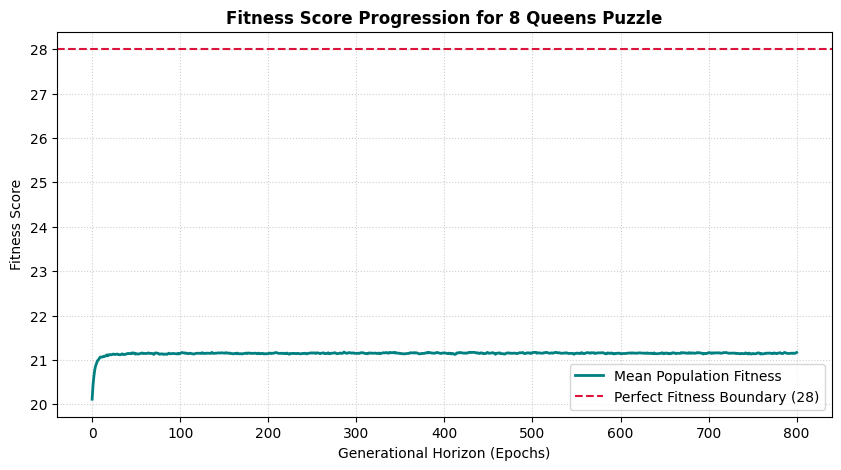

In [287]:
# =====================================================================
# MAIN PIPELINE EXECUTION
# =====================================================================
from tqdm import tqdm

# 1. Hyperparameters and Initialization
POPULATION_SIZE = int(1e5)        # Denoted as N (Must be even)
GENERATIONS = 1000                # Number of evolutionary epochs
MUTATION_RATE = 0.05             # Probability of gene alteration
SELECTION_METHOD = 'softmax'     # 'discrete', 'min_max', or 'softmax'
TEMPERATURE = 10.0
MIN_PROB = 1/(POPULATION_SIZE+1)

# Instantiate initial population matrix (N, 8) and history tracking array
population = initialPopulation(POPULATION_SIZE)
meanFitness_history = np.zeros(GENERATIONS)
bestSolution = None
solutions = [] # Stores unique optimal solutions found

print(f"Starting evolutionary loop using {SELECTION_METHOD} normalization...\n")

# Helper function to check if a NumPy array is in a list of NumPy arrays by value
def is_array_in_list(target_array, list_of_arrays):
    for arr in list_of_arrays:
        if np.array_equal(target_array, arr):
            return True
    return False

# Track actual executed generations for the plot
completed_generations = GENERATIONS

# 2. Generational Loop
for generation in tqdm(range(GENERATIONS)):
    # Early stopping condition if all solutions were found
    if len(solutions) == 92:
        print("All solutions have been found!")
        completed_generations = generation
        break

    # Evaluate performance characteristics of the current population
    fitness = fitnessFunction(population)

    # Track metrics
    fitnessMean = np.mean(fitness)
    meanFitness_history[generation] = fitnessMean
    currentMax = np.max(fitness)

    # Best Solution Appending
    if currentMax == 28:
        found_solution = population[np.argmax(fitness)]
        if not is_array_in_list(found_solution, solutions):
            solutions.append(found_solution)
            print(f"\n--> Solution found at generation {generation}. Solution: {found_solution}")

    # Sequential Function Pipeline
    matingPairs = selection(population, fitness, method=SELECTION_METHOD, temperature=TEMPERATURE, min_prob=MIN_PROB)
    childrenPopulation = crossover(matingPairs)
    population = mutation(childrenPopulation, mutation_rate=MUTATION_RATE)

    # Update completed generations on normal exit of iteration
    completed_generations = generation + 1

print("\nEvolution complete.")
print(f"Total of solutions found: {len(solutions)}")


# 4. Plotting the Optimization Metrics (Adapted to slice only the completed generations)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(completed_generations), meanFitness_history[:completed_generations], color='teal', linewidth=2, label='Mean Population Fitness')
plt.axhline(y=28, color='crimson', linestyle='--', label='Perfect Fitness Boundary (28)')
plt.title('Fitness Score Progression for 8 Queens Puzzle', fontsize=12, fontweight='bold')
plt.xlabel('Generational Horizon (Epochs)', fontsize=10)
plt.ylabel('Fitness Score', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.show()